In [157]:
# Importing important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


In [158]:
# Load the movie dataset from a CSV file into a pandas DataFrame
df = pd.read_csv("/content/movies.csv", on_bad_lines='skip', engine='python')

In [159]:
# Display the first 5 rows of the DataFrame to get a quick overview of the data
df.head()

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


In [160]:
# Display concise summary of the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 4803 non-null   int64  
 1   budget                4803 non-null   int64  
 2   genres                4775 non-null   object 
 3   homepage              1712 non-null   object 
 4   id                    4803 non-null   int64  
 5   keywords              4391 non-null   object 
 6   original_language     4803 non-null   object 
 7   original_title        4803 non-null   object 
 8   overview              4800 non-null   object 
 9   popularity            4803 non-null   float64
 10  production_companies  4803 non-null   object 
 11  production_countries  4803 non-null   object 
 12  release_date          4802 non-null   object 
 13  revenue               4803 non-null   int64  
 14  runtime               4801 non-null   float64
 15  spoken_languages     

In [161]:
# Check for missing values in each column
df.isnull().sum()

,0
index,0
budget,0
genres,28
homepage,3091
id,0
keywords,412
original_language,0
original_title,0
overview,3
popularity,0


In [162]:
# Check for duplicate rows in the DataFrame
df.duplicated().sum()

np.int64(0)

In [163]:
# Display the 'cast' information for the first movie as an example
df["cast"][0]

'Sam Worthington Zoe Saldana Sigourney Weaver Stephen Lang Michelle Rodriguez'

First, ensure your `df` contains the 'cast' column. If you already ran the cell that dropped it, you might need to re-run the initial CSV loading cell to get it back.

/tmp/ipykernel_2334/625124190.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Genre', data=genre_df.head(15), palette='viridis')


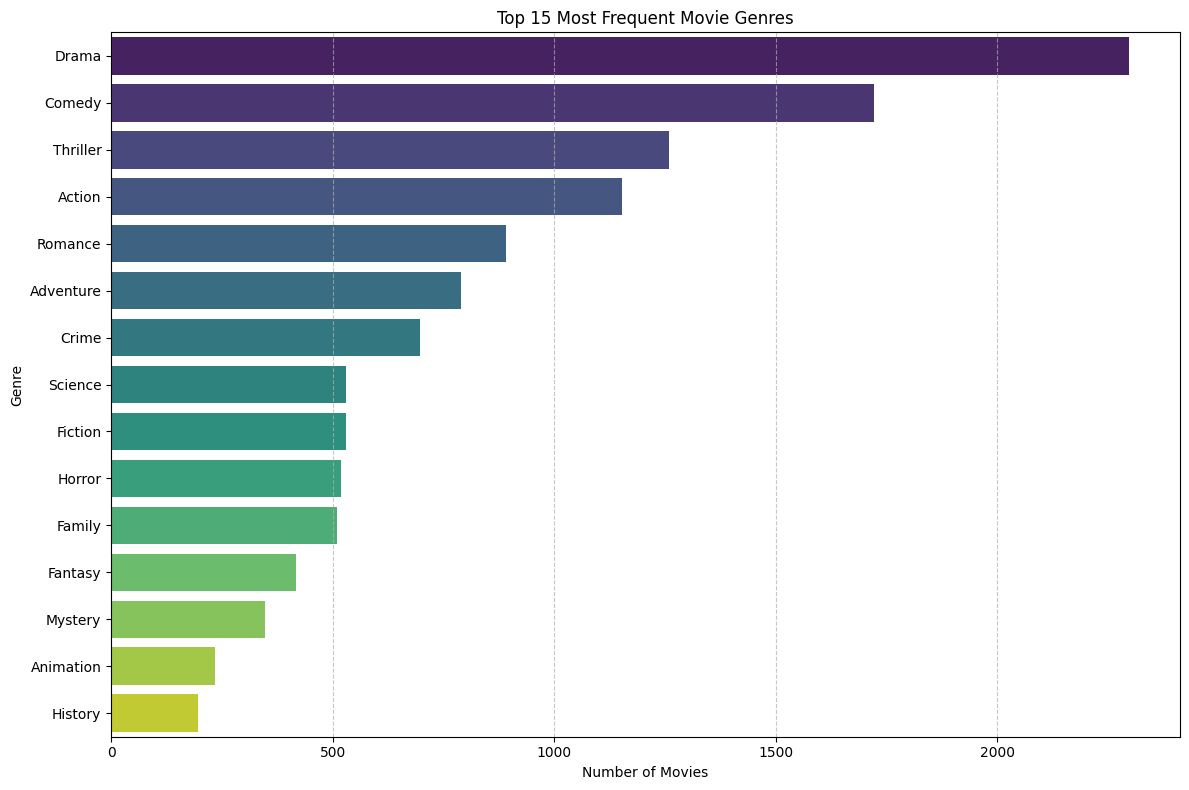

In [164]:
# Split genres string into individual genres and count their occurrences
genres_list = []
for genres in df['genres']:
    # Ensure genres is a string before splitting
    if isinstance(genres, str):
        genres_list.extend(genres.split())

genre_counts = Counter(genres_list)

# Convert to DataFrame for easier plotting
genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count'])
genre_df = genre_df.sort_values(by='Count', ascending=False)

# Plotting the top N genres
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Genre', data=genre_df.head(15), palette='viridis')
plt.title('Top 15 Most Frequent Movie Genres')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [165]:
# Select only the relevant columns for the recommendation system
df = df[["title","overview","genres","tagline","vote_average","popularity","cast"]]

In [166]:
df

,title,overview,genres,tagline,vote_average,popularity,cast
0,Avatar,"In the 22nd century, a paraplegic Marine is di...",Action Adventure Fantasy Science Fiction,Enter the World of Pandora.,7.2,150.437577,Sam Worthington Zoe Saldana Sigourney Weaver S...
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",Adventure Fantasy Action,"At the end of the world, the adventure begins.",6.9,139.082615,Johnny Depp Orlando Bloom Keira Knightley Stel...
2,Spectre,A cryptic message from Bond’s past sends him o...,Action Adventure Crime,A Plan No One Escapes,6.3,107.376788,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...
3,The Dark Knight Rises,Following the death of District Attorney Harve...,Action Crime Drama Thriller,The Legend Ends,7.6,112.312950,Christian Bale Michael Caine Gary Oldman Anne ...
4,John Carter,"John Carter is a war-weary, former military ca...",Action Adventure Science Fiction,"Lost in our world, found in another.",6.1,43.926995,Taylor Kitsch Lynn Collins Samantha Morton Wil...
...,...,...,...,...,...,...,...
4798,El Mariachi,El Mariachi just wants to play his guitar and ...,Action Crime Thriller,"He didn't come looking for trouble, but troubl...",6.6,14.269792,Carlos Gallardo Jaime de Hoyos Peter Marquardt...
4799,Newlyweds,A newlywed couple's honeymoon is upended by th...,Comedy Romance,A newlywed couple's honeymoon is upended by th...,5.9,0.642552,Edward Burns Kerry Bish\u00e9 Marsha Dietlein ...
4800,"Signed, Sealed, Delivered","""Signed, Sealed, Delivered"" introduces a dedic...",Comedy Drama Romance TV Movie,NaN,7.0,1.444476,Eric Mabius Kristin Booth Crystal Lowe Geoff G...
4801,Shanghai Calling,When ambitious New York attorney Sam is sent t...,NaN,A New Yorker in Shanghai,5.7,0.857008,Daniel Henney Eliza Coupe Bill Paxton Alan Ruc...


In [167]:
# Re-check for missing values after column selection
df.isnull().sum()

,0
title,0
overview,3
genres,28
tagline,844
vote_average,0
popularity,0
cast,43


In [168]:
# Fill missing values in the 'genres' column with an empty string
df["genres"]= df["genres"].fillna("")

In [169]:
# Fill missing values in the 'tagline' column with an empty string
df["tagline"] = df["tagline"].fillna("")

In [170]:
# Fill missing values in the 'overview' column with an empty string
df["overview"]= df["overview"].fillna("")

In [171]:
# Fill missing values in the 'cast' column with an empty string
df["cast"]= df["cast"].fillna("")

In [172]:
# Verify that all missing values have been handled
df.isnull().sum()

,0
title,0
overview,0
genres,0
tagline,0
vote_average,0
popularity,0
cast,0


In [173]:
# Combine relevant text features into a single 'tags' column for vectorization
df["tags"] = df["overview"] + " " + df["genres"]+ " " +df["tagline"]

In [174]:
# Display the DataFrame with the new 'tags' column
df.head()

,title,overview,genres,tagline,vote_average,popularity,cast,tags
0,Avatar,"In the 22nd century, a paraplegic Marine is di...",Action Adventure Fantasy Science Fiction,Enter the World of Pandora.,7.2,150.437577,Sam Worthington Zoe Saldana Sigourney Weaver S...,"In the 22nd century, a paraplegic Marine is di..."
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",Adventure Fantasy Action,"At the end of the world, the adventure begins.",6.9,139.082615,Johnny Depp Orlando Bloom Keira Knightley Stel...,"Captain Barbossa, long believed to be dead, ha..."
2,Spectre,A cryptic message from Bond’s past sends him o...,Action Adventure Crime,A Plan No One Escapes,6.3,107.376788,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,A cryptic message from Bond’s past sends him o...
3,The Dark Knight Rises,Following the death of District Attorney Harve...,Action Crime Drama Thriller,The Legend Ends,7.6,112.312950,Christian Bale Michael Caine Gary Oldman Anne ...,Following the death of District Attorney Harve...
4,John Carter,"John Carter is a war-weary, former military ca...",Action Adventure Science Fiction,"Lost in our world, found in another.",6.1,43.926995,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"John Carter is a war-weary, former military ca..."


In [175]:
# Display the 'tags' content for the first movie as an example
df["tags"][0]

'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. Action Adventure Fantasy Science Fiction Enter the World of Pandora.'

In [176]:
# Import NLTK libraries for text processing and scikit-learn for feature extraction
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from  nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer

# Download necessary NLTK data (if not already downloaded)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [177]:
# Convert the 'tags' column to lowercase for consistent text processing
df["tags"] = df["tags"].str.lower()

In [178]:
# Remove punctuation from the 'tags' column
df["tags"] = df["tags"].apply(lambda x:x.translate(str.maketrans("","",string.punctuation)))
df["tags"]

,tags
0,in the 22nd century a paraplegic marine is dis...
1,captain barbossa long believed to be dead has ...
2,a cryptic message from bond’s past sends him o...
3,following the death of district attorney harve...
4,john carter is a warweary former military capt...
...,...
4798,el mariachi just wants to play his guitar and ...
4799,a newlywed couples honeymoon is upended by the...
4800,signed sealed delivered introduces a dedicated...
4801,when ambitious new york attorney sam is sent t...


In [179]:
df["tags"][0]

'in the 22nd century a paraplegic marine is dispatched to the moon pandora on a unique mission but becomes torn between following orders and protecting an alien civilization action adventure fantasy science fiction enter the world of pandora'

In [180]:
# Tokenize the 'tags' column into individual words
df["tags"] = df["tags"].apply(word_tokenize)

In [181]:
# Remove common English stopwords from the tokenized 'tags'
stop_words =set(stopwords.words("english"))
no_stop = []
for x in df["tags"]:
  arr =[]
  for token in x:
    if token not in  stop_words:
      arr.append(token)
  no_stop.append(arr)
df["tags"] = no_stop

In [182]:
# Lemmatize words in the 'tags' column and then join them back into a single string
lemmatizer = WordNetLemmatizer()
df["tags"] = df["tags"].apply(lambda x:[lemmatizer.lemmatize(word) for word in x])
df["tags"] = df["tags"].apply(lambda x:" ".join(x))
df

,title,overview,genres,tagline,vote_average,popularity,cast,tags
0,Avatar,"In the 22nd century, a paraplegic Marine is di...",Action Adventure Fantasy Science Fiction,Enter the World of Pandora.,7.2,150.437577,Sam Worthington Zoe Saldana Sigourney Weaver S...,22nd century paraplegic marine dispatched moon...
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",Adventure Fantasy Action,"At the end of the world, the adventure begins.",6.9,139.082615,Johnny Depp Orlando Bloom Keira Knightley Stel...,captain barbossa long believed dead come back ...
2,Spectre,A cryptic message from Bond’s past sends him o...,Action Adventure Crime,A Plan No One Escapes,6.3,107.376788,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,cryptic message bond ’ past sends trail uncove...
3,The Dark Knight Rises,Following the death of District Attorney Harve...,Action Crime Drama Thriller,The Legend Ends,7.6,112.312950,Christian Bale Michael Caine Gary Oldman Anne ...,following death district attorney harvey dent ...
4,John Carter,"John Carter is a war-weary, former military ca...",Action Adventure Science Fiction,"Lost in our world, found in another.",6.1,43.926995,Taylor Kitsch Lynn Collins Samantha Morton Wil...,john carter warweary former military captain w...
...,...,...,...,...,...,...,...,...
4798,El Mariachi,El Mariachi just wants to play his guitar and ...,Action Crime Thriller,"He didn't come looking for trouble, but troubl...",6.6,14.269792,Carlos Gallardo Jaime de Hoyos Peter Marquardt...,el mariachi want play guitar carry family trad...
4799,Newlyweds,A newlywed couple's honeymoon is upended by th...,Comedy Romance,A newlywed couple's honeymoon is upended by th...,5.9,0.642552,Edward Burns Kerry Bish\u00e9 Marsha Dietlein ...,newlywed couple honeymoon upended arrival resp...
4800,"Signed, Sealed, Delivered","""Signed, Sealed, Delivered"" introduces a dedic...",Comedy Drama Romance TV Movie,,7.0,1.444476,Eric Mabius Kristin Booth Crystal Lowe Geoff G...,signed sealed delivered introduces dedicated q...
4801,Shanghai Calling,When ambitious New York attorney Sam is sent t...,,A New Yorker in Shanghai,5.7,0.857008,Daniel Henney Eliza Coupe Bill Paxton Alan Ruc...,ambitious new york attorney sam sent shanghai ...


In [183]:
# Create a Series mapping movie titles to their DataFrame indices, dropping duplicates
indices = pd.Series(df.index,index = df['title']).drop_duplicates()
indices

,0
title,
Avatar,0
Pirates of the Caribbean: At World's End,1
Spectre,2
The Dark Knight Rises,3
John Carter,4
...,...
El Mariachi,4798
Newlyweds,4799
"Signed, Sealed, Delivered",4800


In [184]:
# Import TfidfVectorizer for converting text data into numerical feature vectors
from sklearn.feature_extraction.text import TfidfVectorizer

In [185]:
# Initialize TfidfVectorizer with parameters: max_features, n-gram range, and English stopwords
tfidf = TfidfVectorizer(max_features=50000,ngram_range=(1,2),stop_words='english')

In [186]:
# Fit the TfidfVectorizer to the 'tags' column and transform the text data into a TF-IDF matrix
tfidf_matrix = tfidf.fit_transform(df['tags'])

In [187]:
# Display the TF-IDF matrix (sparse matrix representation)
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 200266 stored elements and shape (4803, 50000)>

In [188]:
# Import cosine_similarity for calculating similarity between movie vectors
from sklearn.metrics.pairwise import cosine_similarity

In [189]:
# Define the movie recommendation function
def recommend(title, n = 10):
  # Check if the movie title exists in the indices
  if title not in indices:
    return ['Movie not found']

  # Get the index of the movie title
  idx_val = indices[title]

  # Handle cases where multiple movies have the same title (take the first one)
  if isinstance(idx_val, pd.Series):
      idx = idx_val.iloc[0]
  else:
      idx = idx_val

  # Calculate cosine similarity between the input movie and all other movies
  sim_score = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
  # Get the indices of the most similar movies, excluding itself, and take the top 'n'
  similar_idx = sim_score.argsort()[::-1][1:n+1]
  # Return the titles of the recommended movies
  return df['title'].iloc[similar_idx]

In [190]:
# Test the recommendation function with 'Iron Man' and retrieve 10 recommendations
recommend('Iron Man',10)

,title
79,Iron Man 2
94,Guardians of the Galaxy
7,Avengers: Age of Ultron
31,Iron Man 3
1290,Baahubali: The Beginning
538,Hostage
4401,The Helix... Loaded
182,Ant-Man
232,The Wolverine
2492,Steel


In [191]:
# Save the TF-IDF matrix, movie indices, DataFrame, and TF-IDF vectorizer using pickle
import pickle

pickle.dump(tfidf_matrix,open('tfidf_matrix.pkl','wb'))

pickle.dump(indices,open('indices.pkl','wb'))

df.to_pickle('df.pkl')

pickle.dump(tfidf,open('tfidf.pkl','wb'))